Папки созданы: .\artifacts\figures
Используемое устройство: cpu
Локальный STL10 найден
Загружаем STL10 из локальной папки...
STL10 загружен
Данные разделены: Train=4000, Val=1000, Test=8000


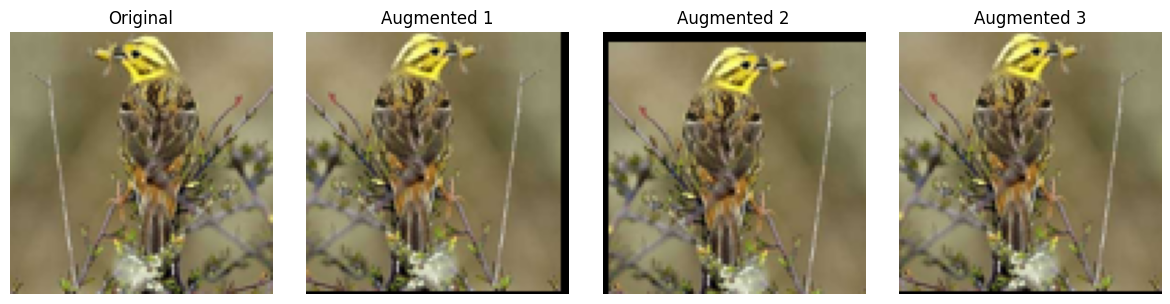

Аугментации визуализированы и сохранены

Запуск эксперимента C1: simple-cnn-base
x.shape: (512, 3, 96, 96) y.shape: (512,)


c:\Users\kiril\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 - Loss: 2.350 / 2.127 | Acc: 0.187 / 0.245
Epoch 2/10 - Loss: 2.016 / 1.879 | Acc: 0.283 / 0.290
Epoch 3/10 - Loss: 1.767 / 1.701 | Acc: 0.366 / 0.344
Epoch 4/10 - Loss: 1.582 / 1.630 | Acc: 0.424 / 0.380
Epoch 5/10 - Loss: 1.459 / 1.576 | Acc: 0.469 / 0.401
Epoch 6/10 - Loss: 1.361 / 1.475 | Acc: 0.508 / 0.451
Epoch 7/10 - Loss: 1.278 / 1.456 | Acc: 0.540 / 0.466
Epoch 8/10 - Loss: 1.220 / 1.476 | Acc: 0.566 / 0.463
Epoch 9/10 - Loss: 1.163 / 1.444 | Acc: 0.590 / 0.473
Epoch 10/10 - Loss: 1.104 / 1.423 | Acc: 0.620 / 0.474

Запуск эксперимента C2: simple-cnn-aug
x.shape: (512, 3, 96, 96) y.shape: (512,)
Epoch 1/10 - Loss: 2.198 / 1.961 | Acc: 0.194 / 0.297
Epoch 2/10 - Loss: 1.879 / 1.791 | Acc: 0.318 / 0.355
Epoch 3/10 - Loss: 1.703 / 1.640 | Acc: 0.391 / 0.408
Epoch 4/10 - Loss: 1.582 / 1.558 | Acc: 0.425 / 0.422
Epoch 5/10 - Loss: 1.497 / 1.512 | Acc: 0.455 / 0.445
Epoch 6/10 - Loss: 1.445 / 1.495 | Acc: 0.470 / 0.450
Epoch 7/10 - Loss: 1.385 / 1.465 | Acc: 0.504 / 0.479

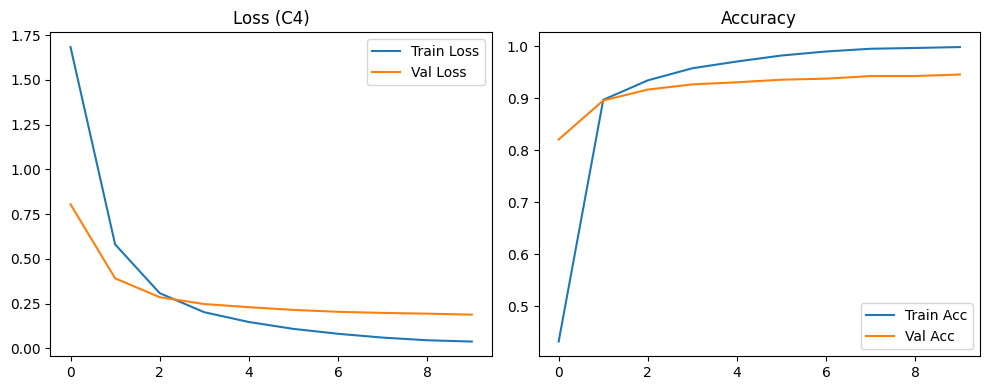

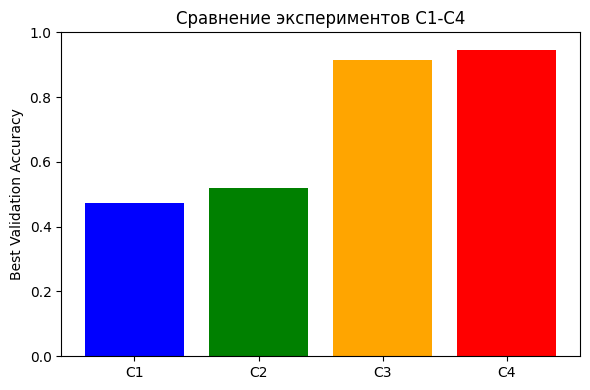

Артефакты Части A сохранены


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple-cnn-base,Adam,0.0010,10,0.474,NaN,None,None,None,Best val acc 0.4740
1,C2,classification,STL10,42,simple-cnn-aug,Adam,0.0010,10,0.518,NaN,None,None,None,Best val acc 0.5180
2,C3,classification,STL10,42,resnet18-head-only,Adam,0.0010,10,0.915,NaN,None,None,None,Best val acc 0.9150
3,C4,classification,STL10,42,resnet18-finetune,Adam,0.0001,10,0.946,0.9443,None,None,None,Best val acc 0.9460


In [1]:
import os
import json
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models

homeworkDir = "."
data_dir = os.path.join(homeworkDir, "data")
artifacts = os.path.join(homeworkDir, "artifacts")
figures = os.path.join(artifacts, "figures")

os.makedirs(figures, exist_ok=True)
print(f"Папки созданы: {figures}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

results_log = []

stl10_dir = os.path.join(data_dir, "stl10_binary")
required_stl10 = [
    "train_X.bin",
    "train_y.bin",
    "test_X.bin",
    "test_y.bin",
    "unlabeled_X.bin",
    "class_names.txt",
    "fold_indices.txt",
]

for name in required_stl10:
    path = os.path.join(stl10_dir, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Не найден файл STL10: {path}")

print("Локальный STL10 найден")

transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

resnet_weights = models.ResNet18_Weights.DEFAULT
transform_resnet_base = resnet_weights.transforms()
transform_resnet_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transform_resnet_base
])

print("Загружаем STL10 из локальной папки...")
raw_train_dataset = datasets.STL10(root=data_dir, split="train", download=False, transform=None)
raw_test_dataset = datasets.STL10(root=data_dir, split="test", download=False, transform=None)
print("STL10 загружен")

class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

indices = list(range(len(raw_train_dataset)))
rng = np.random.default_rng(42)
rng.shuffle(indices)
train_idx, val_idx = indices[:4000], indices[4000:]

print(f"Данные разделены: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(raw_test_dataset)}")

sample_img, _ = raw_train_dataset[0]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample_img)
axes[0].set_title("Original")
axes[0].axis("off")

vis_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomCrop(96, padding=4)
])

for i in range(1, 4):
    axes[i].imshow(vis_aug(sample_img))
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures, "augmentations_preview.png"))
plt.show()
print("Аугментации визуализированы и сохранены")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 24 * 24, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def get_resnet_model(mode="head_only", num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if mode == "head_only":
        for param in model.parameters():
            param.requires_grad = False
    elif mode == "finetune":
        for name, param in model.named_parameters():
            if not name.startswith("layer4") and not name.startswith("fc"):
                param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += labels.size(0)

    return running_loss / total, correct / total

EPOCHS = 10
BATCH_SIZE = 512

experiments = [
    {"id": "C1", "name": "simple-cnn-base", "model_fn": lambda: SimpleCNN(), "t_train": transform_base, "t_val": transform_base, "lr": 1e-3},
    {"id": "C2", "name": "simple-cnn-aug", "model_fn": lambda: SimpleCNN(), "t_train": transform_aug, "t_val": transform_base, "lr": 1e-3},
    {"id": "C3", "name": "resnet18-head-only", "model_fn": lambda: get_resnet_model("head_only"), "t_train": transform_resnet_aug, "t_val": transform_resnet_base, "lr": 1e-3},
    {"id": "C4", "name": "resnet18-finetune", "model_fn": lambda: get_resnet_model("finetune"), "t_train": transform_resnet_aug, "t_val": transform_resnet_base, "lr": 1e-4},
]

best_overall_acc = 0.0
best_model_state = None
best_model_config = None
best_history = None
histories_full = {}

for exp in experiments:
    print(f"\nЗапуск эксперимента {exp['id']}: {exp['name']}")

    train_ds = SubsetWithTransform(raw_train_dataset, train_idx, transform=exp["t_train"])
    val_ds = SubsetWithTransform(raw_train_dataset, val_idx, transform=exp["t_val"])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    x_check, y_check = next(iter(train_loader))
    print("x.shape:", tuple(x_check.shape), "y.shape:", tuple(y_check.shape))

    model = exp["model_fn"]().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=exp["lr"])

    best_val_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(EPOCHS):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        if va > best_val_acc:
            best_val_acc = va

        if va > best_overall_acc:
            best_overall_acc = va
            best_model_state = copy.deepcopy(model.state_dict())
            best_history = copy.deepcopy(history)
            best_model_config = {
                "best_experiment_id": exp["id"],
                "model": exp["name"],
                "dataset": "STL10",
                "lr": exp["lr"],
                "epochs": EPOCHS,
                "seed": 42,
                "transforms": {
                    "train_transforms": str(exp["t_train"]),
                    "val_test_transforms": str(exp["t_val"]),
                }
            }

        print(f"Epoch {epoch + 1}/{EPOCHS} - Loss: {tl:.3f} / {vl:.3f} | Acc: {ta:.3f} / {va:.3f}")

    histories_full[exp["id"]] = copy.deepcopy(history)

    results_log.append({
        "experiment_id": exp["id"],
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": exp["name"],
        "optimizer": "Adam",
        "lr": exp["lr"],
        "epochs_trained": EPOCHS,
        "best_val_accuracy": round(best_val_acc, 4),
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": f"Best val acc {best_val_acc:.4f}"
    })

print(f"\nЛучшая модель: {best_model_config['best_experiment_id']} ({best_model_config['model']}) с Val Acc = {best_overall_acc:.4f}")

best_model = next(item["model_fn"] for item in experiments if item["id"] == best_model_config["best_experiment_id"])().to(device)
best_model.load_state_dict(best_model_state)

best_test_transform = next(item["t_val"] for item in experiments if item["id"] == best_model_config["best_experiment_id"])
test_ds = SubsetWithTransform(raw_test_dataset, list(range(len(raw_test_dataset))), transform=best_test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

_, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Итоговая Test Accuracy: {test_acc:.4f}")

for row in results_log:
    if row["experiment_id"] == best_model_config["best_experiment_id"]:
        row["test_accuracy"] = round(test_acc, 4)

torch.save(best_model_state, os.path.join(artifacts, "best_classifier.pt"))

best_model_config["test_accuracy"] = round(test_acc, 4)
with open(os.path.join(artifacts, "best_classifier_config.json"), "w", encoding="utf-8") as f:
    json.dump(best_model_config, f, indent=4, ensure_ascii=False)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(best_history["train_loss"], label="Train Loss")
plt.plot(best_history["val_loss"], label="Val Loss")
plt.legend()
plt.title(f"Loss ({best_model_config['best_experiment_id']})")

plt.subplot(1, 2, 2)
plt.plot(best_history["train_acc"], label="Train Acc")
plt.plot(best_history["val_acc"], label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.tight_layout()
plt.savefig(os.path.join(figures, "classification_curves_best.png"))
plt.show()

plt.figure(figsize=(6, 4))
best_vals = [max(histories_full[k]["val_acc"]) for k in ["C1", "C2", "C3", "C4"]]
plt.bar(["C1", "C2", "C3", "C4"], best_vals, color=["blue", "green", "orange", "red"])
plt.ylabel("Best Validation Accuracy")
plt.title("Сравнение экспериментов C1-C4")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(figures, "classification_compare.png"))
plt.show()

with open(os.path.join(artifacts, "part_a_results.json"), "w", encoding="utf-8") as f:
    json.dump(results_log, f, indent=4, ensure_ascii=False)

print("Артефакты Части A сохранены")
display(pd.DataFrame(results_log))

Используемое устройство: cpu
Загружаем OxfordIIITPet segmentation из локальной папки...
OxfordIIITPet загружен: 3669 изображений
Part B x.shape: (4, 3, 224, 224)
Part B y.shape: (4, 224, 224)
Выполняем segmentation inference...
V1: Precision=0.7472, Recall=0.9739, MeanIoU=0.7307
V2: Precision=0.6169, Recall=0.9906, MeanIoU=0.6128


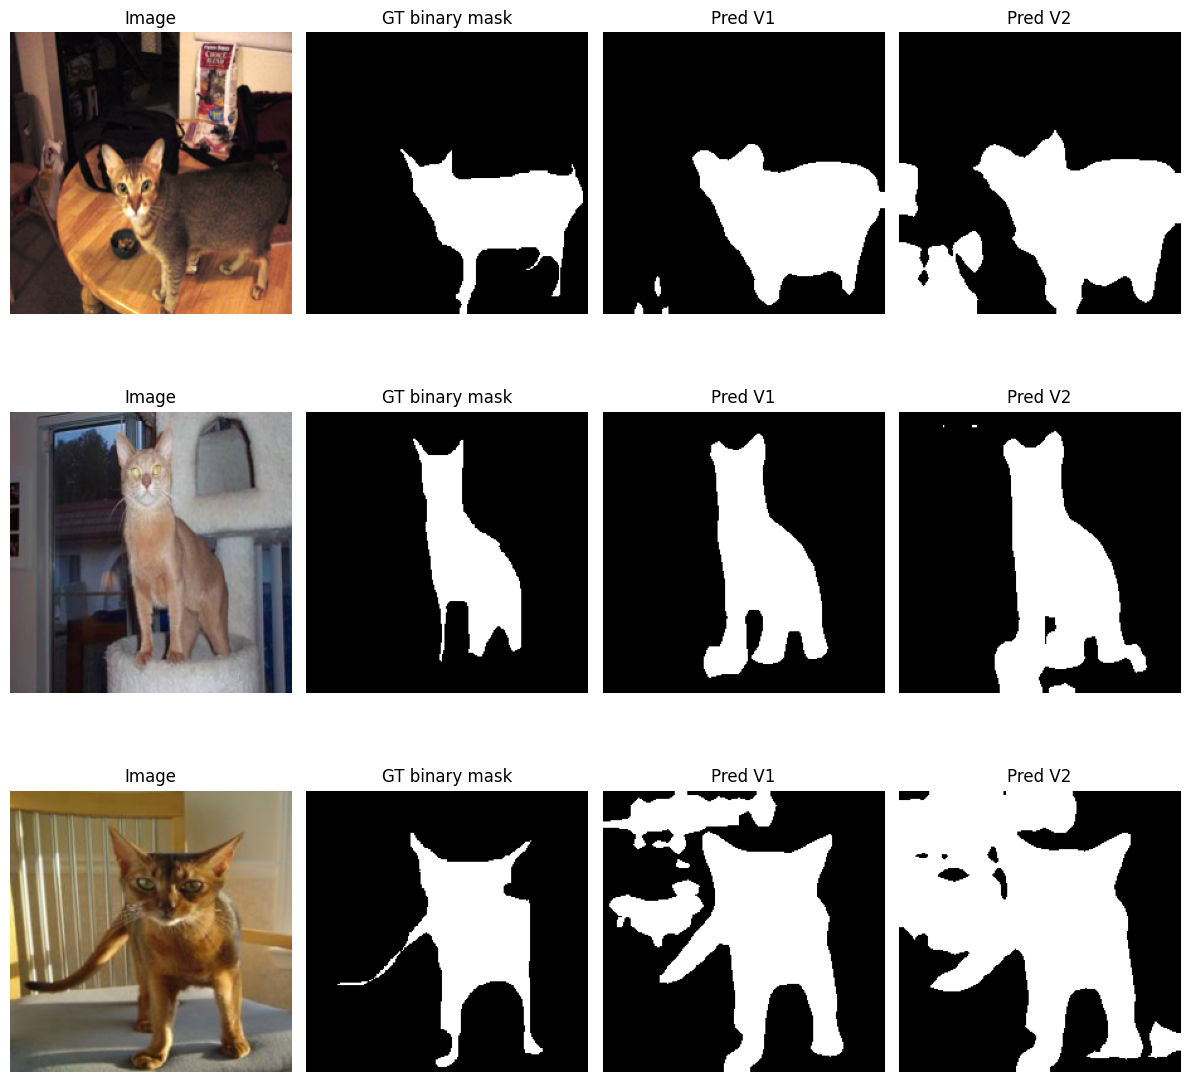

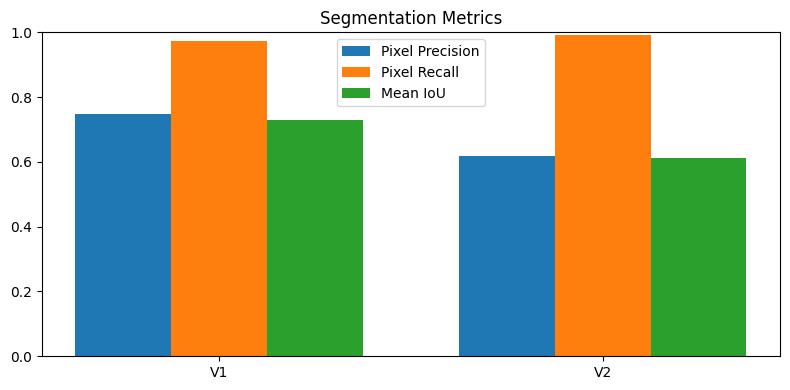

Файл runs.csv успешно сохранен


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple-cnn-base,Adam,0.0010,10.0,0.474,NaN,NaN,NaN,NaN,Best val acc 0.4740
1,C2,classification,STL10,42,simple-cnn-aug,Adam,0.0010,10.0,0.518,NaN,NaN,NaN,NaN,Best val acc 0.5180
2,C3,classification,STL10,42,resnet18-head-only,Adam,0.0010,10.0,0.915,NaN,NaN,NaN,NaN,Best val acc 0.9150
3,C4,classification,STL10,42,resnet18-finetune,Adam,0.0001,10.0,0.946,0.9443,NaN,NaN,NaN,Best val acc 0.9460
4,V1,segmentation,OxfordIIITPet,42,FCN_ResNet50,None,NaN,NaN,NaN,NaN,0.7472,0.9739,0.7307,V1 argmax foreground>0
5,V2,segmentation,OxfordIIITPet,42,FCN_ResNet50,None,NaN,NaN,NaN,NaN,0.6169,0.9906,0.6128,V2 threshold on foreground prob 0.3


In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
from PIL import Image

homeworkDir = "."
data_dir = os.path.join(homeworkDir, "data")
artifacts = os.path.join(homeworkDir, "artifacts")
figures = os.path.join(artifacts, "figures")

os.makedirs(figures, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

pet_dir = os.path.join(data_dir, "oxford-iiit-pet")
pet_images_dir = os.path.join(pet_dir, "images")
pet_annotations_dir = os.path.join(pet_dir, "annotations")

if not os.path.isdir(pet_images_dir):
    raise FileNotFoundError(f"Не найдена папка: {pet_images_dir}")

if not os.path.isdir(pet_annotations_dir):
    raise FileNotFoundError(f"Не найдена папка: {pet_annotations_dir}")

part_a_json = os.path.join(artifacts, "part_a_results.json")
if os.path.exists(part_a_json):
    with open(part_a_json, "r", encoding="utf-8") as f:
        results_log = json.load(f)
else:
    results_log = []

print("Загружаем OxfordIIITPet segmentation из локальной папки...")

seg_weights = FCN_ResNet50_Weights.DEFAULT
seg_model = fcn_resnet50(weights=seg_weights).to(device)
seg_model.eval()

IMG_SIZE = 224

img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

vis_transform = transforms.Resize((IMG_SIZE, IMG_SIZE))
mask_transform = transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.NEAREST)

class OxfordPetBinarySegmentation(torch.utils.data.Dataset):
    def __init__(self, root, split="test"):
        self.ds = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=False
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]

        img_vis = vis_transform(img)
        img_vis_np = np.array(img_vis, dtype=np.uint8)

        img_tensor = img_transform(img)

        mask_resized = mask_transform(mask)
        mask_np = np.array(mask_resized, dtype=np.uint8)
        binary_mask = (mask_np == 1).astype(np.uint8)

        return img_vis_np, img_tensor, torch.from_numpy(binary_mask)

def seg_collate_fn(batch):
    vis_imgs = [item[0] for item in batch]
    img_tensors = torch.stack([item[1] for item in batch], dim=0)
    gt_masks = torch.stack([item[2] for item in batch], dim=0)
    return vis_imgs, img_tensors, gt_masks

seg_test_ds = OxfordPetBinarySegmentation(data_dir, split="test")
seg_test_loader = DataLoader(
    seg_test_ds,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=seg_collate_fn
)

print(f"OxfordIIITPet загружен: {len(seg_test_ds)} изображений")

vis_check, x_check, y_check = next(iter(seg_test_loader))
print("Part B x.shape:", tuple(x_check.shape))
print("Part B y.shape:", tuple(y_check.shape))

def binary_metrics(pred_mask, gt_mask):
    pred = pred_mask.bool()
    gt = gt_mask.bool()

    tp = (pred & gt).sum().item()
    fp = (pred & ~gt).sum().item()
    fn = (~pred & gt).sum().item()

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    iou = tp / (tp + fp + fn + 1e-6)
    return precision, recall, iou

def postprocess_v1(logits):
    pred_classes = logits.argmax(dim=1)
    return (pred_classes > 0).to(torch.uint8)

def postprocess_v2(logits):
    probs = torch.softmax(logits, dim=1)
    foreground_prob = 1.0 - probs[:, 0]
    return (foreground_prob >= 0.3).to(torch.uint8)

NUM_EVAL_BATCHES = 20
metrics_res = {
    "V1": {"precisions": [], "recalls": [], "ious": []},
    "V2": {"precisions": [], "recalls": [], "ious": []},
}

saved_batch = None

print("Выполняем segmentation inference...")
with torch.no_grad():
    for batch_idx, batch in enumerate(seg_test_loader):
        vis_imgs, img_tensors, gt_masks = batch
        img_tensors = img_tensors.to(device)

        outputs = seg_model(img_tensors)["out"]

        pred_v1 = postprocess_v1(outputs).cpu()
        pred_v2 = postprocess_v2(outputs).cpu()

        for i in range(img_tensors.size(0)):
            p1, r1, i1 = binary_metrics(pred_v1[i], gt_masks[i])
            p2, r2, i2 = binary_metrics(pred_v2[i], gt_masks[i])

            metrics_res["V1"]["precisions"].append(p1)
            metrics_res["V1"]["recalls"].append(r1)
            metrics_res["V1"]["ious"].append(i1)

            metrics_res["V2"]["precisions"].append(p2)
            metrics_res["V2"]["recalls"].append(r2)
            metrics_res["V2"]["ious"].append(i2)

        if saved_batch is None:
            saved_batch = (vis_imgs, gt_masks, pred_v1, pred_v2)

        if batch_idx + 1 >= NUM_EVAL_BATCHES:
            break

for mode in ["V1", "V2"]:
    precision = float(np.mean(metrics_res[mode]["precisions"]))
    recall = float(np.mean(metrics_res[mode]["recalls"]))
    mean_iou = float(np.mean(metrics_res[mode]["ious"]))

    print(f"{mode}: Precision={precision:.4f}, Recall={recall:.4f}, MeanIoU={mean_iou:.4f}")

    results_log.append({
        "experiment_id": mode,
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": 42,
        "model_summary": "FCN_ResNet50",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_accuracy": None,
        "test_accuracy": None,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "mean_iou": round(mean_iou, 4),
        "notes": "V1 argmax foreground>0" if mode == "V1" else "V2 threshold on foreground prob 0.3"
    })

vis_imgs, gt_masks, pred_v1, pred_v2 = saved_batch

n_show = min(3, len(vis_imgs))
fig, axes = plt.subplots(n_show, 4, figsize=(12, 4 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(n_show):
    axes[i, 0].imshow(vis_imgs[i])
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt_masks[i].numpy(), cmap="gray")
    axes[i, 1].set_title("GT binary mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_v1[i].numpy(), cmap="gray")
    axes[i, 2].set_title("Pred V1")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(pred_v2[i].numpy(), cmap="gray")
    axes[i, 3].set_title("Pred V2")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures, "segmentation_examples.png"))
plt.show()

v1_iou = float(np.mean(metrics_res["V1"]["ious"]))
v2_iou = float(np.mean(metrics_res["V2"]["ious"]))
v1_prec = float(np.mean(metrics_res["V1"]["precisions"]))
v2_prec = float(np.mean(metrics_res["V2"]["precisions"]))
v1_rec = float(np.mean(metrics_res["V1"]["recalls"]))
v2_rec = float(np.mean(metrics_res["V2"]["recalls"]))

x = np.arange(2)
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, [v1_prec, v2_prec], width, label="Pixel Precision")
ax.bar(x, [v1_rec, v2_rec], width, label="Pixel Recall")
ax.bar(x + width, [v1_iou, v2_iou], width, label="Mean IoU")
ax.set_xticks(x)
ax.set_xticklabels(["V1", "V2"])
ax.set_ylim(0, 1.0)
ax.set_title("Segmentation Metrics")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures, "segmentation_metrics.png"))
plt.show()

df_results = pd.DataFrame(results_log)
df_results.to_csv(os.path.join(artifacts, "runs.csv"), index=False, encoding="utf-8")

print("Файл runs.csv успешно сохранен")
display(df_results)